In [1]:
from glob import glob
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import constants as C

In [2]:
RESET_MERGE = False

In [3]:
def concat_yearly_data(file_list, usecols):
	data_frames = []
	for file in file_list:
		df = pd.read_csv(file, usecols=usecols, encoding="latin-1", low_memory=False)
		year = file.split('\\')[1].replace('FARS', '').replace('NationalCSV', '')
		df['YEAR'] = int(year)
		data_frames.append(df)
	combined_df = pd.concat(data_frames, ignore_index=True)
	return combined_df


def merge_dataframes(acc_df, dist_df, veh_df, pers_df):
	distract_vehicle = dist_df.merge(
		veh_df, on=['ST_CASE', 'STATE', 'YEAR', 'VEH_NO'], how='left')
	distract_vehicle_accident = distract_vehicle.merge(
		acc_df, on=['ST_CASE', 'STATE', 'YEAR'], how='left')
	full_merged = distract_vehicle_accident.merge(
		pers_df, on=['ST_CASE', 'STATE', 'YEAR', 'VEH_NO'], how='left')
	return full_merged

In [4]:
if RESET_MERGE:
	accident_files = glob(C.ACCIDENT_PATH)
	print(f"Number of accident files found: {len(accident_files)}")

	accident_concatenated = concat_yearly_data(accident_files, C.accident_cols)
	print(f"Concatenated ACCIDENT data shape: {accident_concatenated.shape}")
	print("Columns in concatenated ACCIDENT data:")
	print(accident_concatenated.columns)

	#################################################################################
	distract_files = glob(C.DISTRACT_PATH)
	print(f"\nNumber of distraction files found: {len(distract_files)}")

	distract_concatenated = concat_yearly_data(distract_files, C.distract_cols)
	print(f"Concatenated DISTRACTION data shape: {distract_concatenated.shape}")
	print("Columns in concatenated DISTRACTION data:")
	print(distract_concatenated.columns)

	#################################################################################
	vehicle_files = glob(C.VEHICLE_PATH)
	print(f"\nNumber of vehicle files found: {len(vehicle_files)}")

	vehicle_concatenated = concat_yearly_data(vehicle_files, C.vehicle_cols)
	print(f"Concatenated VEHICLE data shape: {vehicle_concatenated.shape}")
	print("Columns in concatenated VEHICLE data:")
	print(vehicle_concatenated.columns)

	#################################################################################
	person_files = glob(C.PERSON_PATH)
	print(f"\nNumber of person files found: {len(person_files)}")

	person_concatenated = concat_yearly_data(person_files, C.person_cols)
	print(f"Concatenated PERSON data shape: {person_concatenated.shape}")
	print("Columns in concatenated PERSON data:")
	print(person_concatenated.columns)

	#################################################################################
	df = merge_dataframes(accident_concatenated, distract_concatenated,
	                      vehicle_concatenated, person_concatenated)
	print(f"\nMerged DataFrame shape: {df.shape}")

	print(f"\nSaving merged file to: {C.MERGED_DATA_PATH}")
	df.to_csv(C.MERGED_DATA_PATH, index=False)

else:
	df = pd.read_csv(C.MERGED_DATA_PATH, low_memory=False)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 726930 entries, 0 to 726929
Data columns (total 26 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STATE     726930 non-null  int64  
 1   ST_CASE   726930 non-null  int64  
 2   VEH_NO    726930 non-null  int64  
 3   MDRDSTRD  726930 non-null  int64  
 4   YEAR      726930 non-null  int64  
 5   NUMOCCS   725804 non-null  float64
 6   MAKE      725804 non-null  float64
 7   MOD_YEAR  725804 non-null  float64
 8   PREV_ACC  725539 non-null  float64
 9   PREV_DWI  725539 non-null  float64
 10  COUNTY    726930 non-null  int64  
 11  CITY      726930 non-null  int64  
 12  DAY       726930 non-null  int64  
 13  MONTH     726930 non-null  int64  
 14  DAY_WEEK  726930 non-null  int64  
 15  HOUR      726930 non-null  int64  
 16  MINUTE    726930 non-null  int64  
 17  LGT_COND  726930 non-null  int64  
 18  WEATHER   726930 non-null  int64  
 19  FATALS    726930 non-null  int64  
 20  PER_

In [6]:
df.head().T

,0,1,2,3,4
STATE,1.0,1.0,1.0,1.0,1.0
ST_CASE,10001.0,10001.0,10002.0,10003.0,10003.0
VEH_NO,1.0,1.0,1.0,1.0,2.0
MDRDSTRD,0.0,0.0,0.0,0.0,0.0
YEAR,2010.0,2010.0,2010.0,2010.0,2010.0
NUMOCCS,2.0,2.0,1.0,1.0,1.0
MAKE,12.0,12.0,9.0,53.0,49.0
MOD_YEAR,2000.0,2000.0,1998.0,2005.0,2008.0
PREV_ACC,98.0,98.0,0.0,1.0,1.0
PREV_DWI,0.0,0.0,0.0,0.0,0.0


## Preprocessing

In [7]:
# Convert to minimal dtypes
for col in df.columns:
    try:
        df[col] = df[col].astype('int16')
    except Exception as e:
        print(f'Failed for column: {col} because of err: {e}')
        pass

Failed for column: NUMOCCS because of err: Cannot convert non-finite values (NA or inf) to integer
Failed for column: MAKE because of err: Cannot convert non-finite values (NA or inf) to integer
Failed for column: MOD_YEAR because of err: Cannot convert non-finite values (NA or inf) to integer
Failed for column: PREV_ACC because of err: Cannot convert non-finite values (NA or inf) to integer
Failed for column: PREV_DWI because of err: Cannot convert non-finite values (NA or inf) to integer
Failed for column: PER_NO because of err: Cannot convert non-finite values (NA or inf) to integer
Failed for column: AGE because of err: Cannot convert non-finite values (NA or inf) to integer
Failed for column: SEX because of err: Cannot convert non-finite values (NA or inf) to integer
Failed for column: PER_TYP because of err: Cannot convert non-finite values (NA or inf) to integer
Failed for column: INJ_SEV because of err: Cannot convert non-finite values (NA or inf) to integer
Failed for column: 

In [8]:
# 1. Map codes to categories in the main DataFrame
def apply_distraction_category(row):
	for category, codes in C.distraction_categories.items():
		if int(row['MDRDSTRD']) in codes:
			return category
	print(f"Unmapped code found: {row['MDRDSTRD']}")

df_fatal_drivers = df.copy()
df_fatal_drivers['DISTRACT_GROUP'] = df_fatal_drivers.apply(apply_distraction_category, axis=1)
df_fatal_drivers.head()

,STATE,ST_CASE,VEH_NO,MDRDSTRD,YEAR,NUMOCCS,MAKE,MOD_YEAR,PREV_ACC,PREV_DWI,...,LGT_COND,WEATHER,FATALS,PER_NO,AGE,SEX,PER_TYP,INJ_SEV,HISPANIC,DISTRACT_GROUP
0,1,10001,1,0,2010,2.0,12.0,2000.0,98.0,0.0,...,3,1,1,1.0,51.0,2.0,1.0,4.0,7.0,Not Distracted/Unknown
1,1,10001,1,0,2010,2.0,12.0,2000.0,98.0,0.0,...,3,1,1,2.0,999.0,1.0,2.0,3.0,0.0,Not Distracted/Unknown
2,1,10002,1,0,2010,1.0,9.0,1998.0,0.0,0.0,...,3,1,1,1.0,44.0,2.0,1.0,4.0,7.0,Not Distracted/Unknown
3,1,10003,1,0,2010,1.0,53.0,2005.0,1.0,0.0,...,1,1,1,1.0,27.0,1.0,1.0,4.0,7.0,Not Distracted/Unknown
4,1,10003,2,0,2010,1.0,49.0,2008.0,1.0,0.0,...,1,1,1,1.0,45.0,2.0,1.0,0.0,0.0,Not Distracted/Unknown


In [9]:
# 2. Filter out 'Unknown'/'Not Distracted' for proportional analysis
# Assuming 'Unknown' covers code 0 (Not Distracted) and other non-distraction codes
df_distracted = df_fatal_drivers[df_fatal_drivers['DISTRACT_GROUP'] != 'Not Distracted/Unknown'].copy()
df_distracted.shape

(37116, 27)

In [10]:
df_distracted.head()

,STATE,ST_CASE,VEH_NO,MDRDSTRD,YEAR,NUMOCCS,MAKE,MOD_YEAR,PREV_ACC,PREV_DWI,...,LGT_COND,WEATHER,FATALS,PER_NO,AGE,SEX,PER_TYP,INJ_SEV,HISPANIC,DISTRACT_GROUP
110,1,10049,1,15,2010,1.0,20.0,2001.0,98.0,2.0,...,1,1,1,1.0,23.0,1.0,1.0,0.0,0.0,Mobile Phone
185,1,10080,1,6,2010,1.0,20.0,1997.0,0.0,0.0,...,1,1,1,1.0,20.0,2.0,1.0,4.0,7.0,Mobile Phone
217,1,10094,1,10,2010,1.0,21.0,2003.0,0.0,0.0,...,3,1,1,1.0,19.0,2.0,1.0,4.0,7.0,Car Controls/Devices
230,1,10102,1,3,2010,3.0,37.0,2001.0,0.0,0.0,...,1,1,1,1.0,21.0,2.0,1.0,0.0,0.0,Passenger/Moving Objects
231,1,10102,1,3,2010,3.0,37.0,2001.0,0.0,0.0,...,1,1,1,2.0,999.0,1.0,2.0,0.0,0.0,Passenger/Moving Objects


In [11]:
# 3. Group and calculate annual totals for proportion
summary_df = df_distracted.groupby('YEAR')['FATALS'].sum().reset_index()
summary_df.rename(
    columns={'FATALS': 'Total_Distracted_Fatalities'}, inplace=True
)
summary_df

,YEAR,Total_Distracted_Fatalities
0,2010,2986
1,2011,2870
2,2012,4579
3,2013,4550
4,2014,4529
5,2015,5019
6,2016,5290
7,2017,4529
8,2018,3866
9,2019,4081


In [12]:
# 4. Calculate Mobile Phone Fatalities
mobile_phone_df = df_distracted[
    df_distracted['DISTRACT_GROUP'] == 'Mobile Phone'
].groupby('YEAR')['FATALS'].sum().reset_index()
mobile_phone_df.rename(columns={'FATALS': 'Mobile_Phone_Fatalities'}, inplace=True)
mobile_phone_df

,YEAR,Mobile_Phone_Fatalities
0,2010,684
1,2011,651
2,2012,629
3,2013,673
4,2014,583
5,2015,732
6,2016,978
7,2017,681
8,2018,531
9,2019,566


In [13]:
# 5. Merge and calculate the proportion
summary_final = summary_df.merge(mobile_phone_df, on='YEAR', how='left')
summary_final['Mobile_Phone_Proportion'] = (
    summary_final['Mobile_Phone_Fatalities'] /
    summary_final['Total_Distracted_Fatalities']
)
summary_final['Year_Index'] = summary_final['YEAR'] - summary_final['YEAR'].min() + 1
summary_final.to_csv(C.SUMMARY_DATA_PATH, index=False)
summary_final

,YEAR,Total_Distracted_Fatalities,Mobile_Phone_Fatalities,Mobile_Phone_Proportion,Year_Index
0,2010,2986,684,0.229069,1
1,2011,2870,651,0.226829,2
2,2012,4579,629,0.137366,3
3,2013,4550,673,0.147912,4
4,2014,4529,583,0.128726,5
5,2015,5019,732,0.145846,6
6,2016,5290,978,0.184877,7
7,2017,4529,681,0.150364,8
8,2018,3866,531,0.137351,9
9,2019,4081,566,0.138691,10


## Visualizations

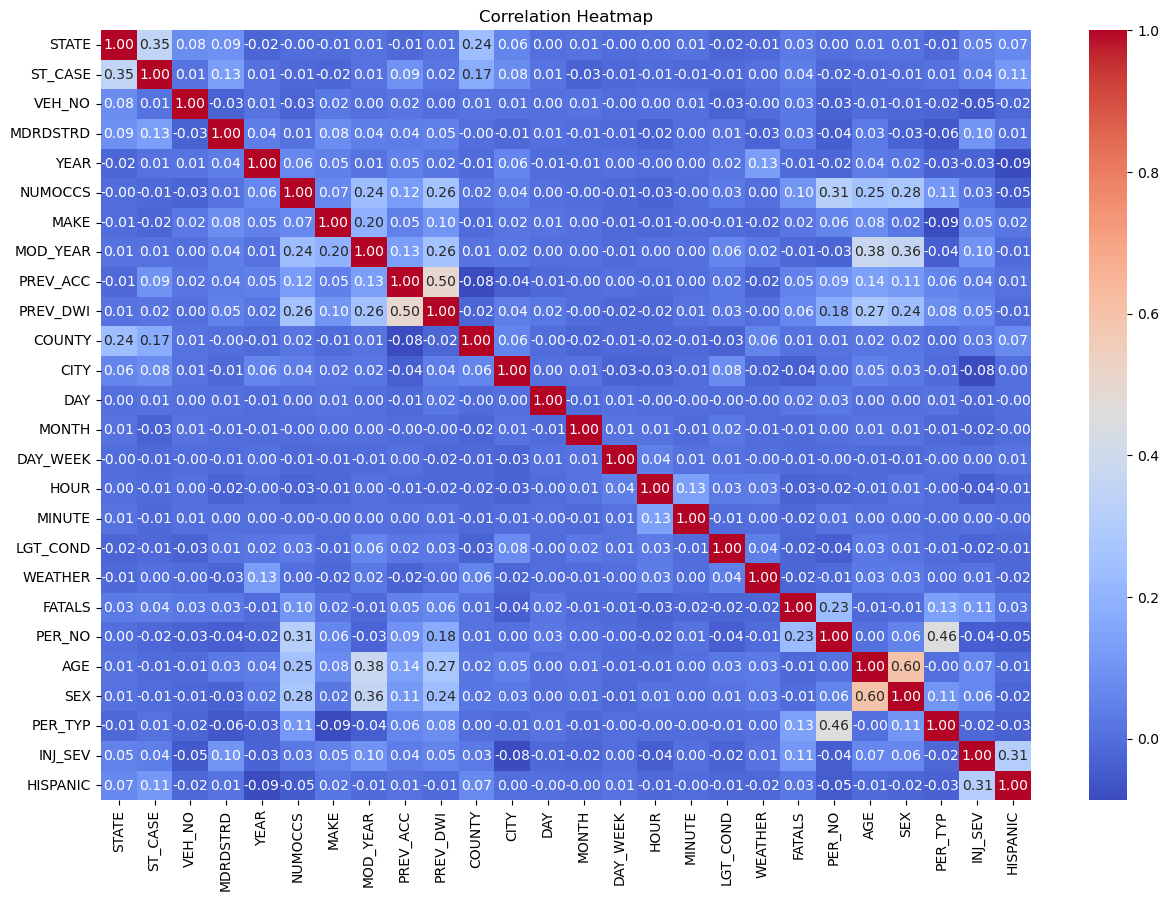

In [14]:
# Heatmap of correlations
plt.figure(figsize=(15, 10))
sns.heatmap(df_distracted.drop('DISTRACT_GROUP', axis=1).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Linear Trend: Mobile Phone Proportion vs. Year

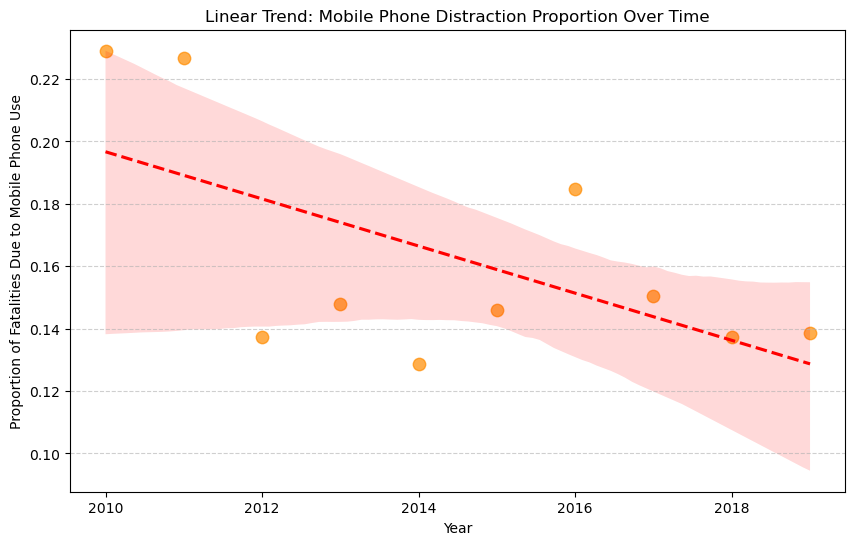

In [15]:
# Assuming summary_final contains 'YEAR' and 'Mobile_Phone_Proportion'
plt.figure(figsize=(10, 6))

# Use regplot for a scatter plot with a regression line fit
sns.regplot(
    data=summary_final,
    x='YEAR',
    y='Mobile_Phone_Proportion',
    scatter_kws={'s': 80, 'alpha': 0.7, 'color': 'darkorange'},
    line_kws={'color': 'red', 'linestyle': '--'}
)

plt.title('Linear Trend: Mobile Phone Distraction Proportion Over Time')
plt.xlabel('Year')
plt.ylabel('Proportion of Fatalities Due to Mobile Phone Use')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### 2. Hypothesis Test Comparison: Early vs. Late Period

C:\Users\ikath\AppData\Local\Temp\ipykernel_17824\1396273884.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  period_means = summary_final.groupby(
C:\Users\ikath\AppData\Local\Temp\ipykernel_17824\1396273884.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


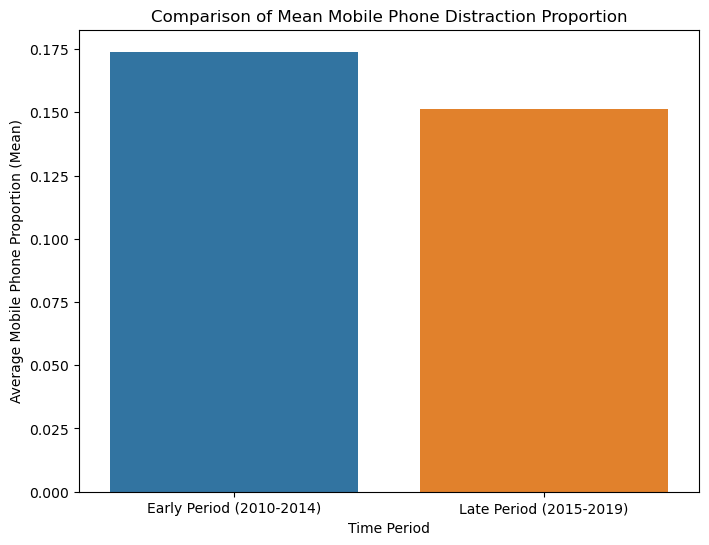

In [16]:
# 1. Create a period column
period_breaks = [2010, 2015, 2020]
period_labels = ['Early Period (2010-2014)', 'Late Period (2015-2019)']

summary_final['Period'] = pd.cut(
    summary_final['YEAR'],
    bins=period_breaks,
    labels=period_labels,
    right=False
)

# 2. Group by the new period
period_means = summary_final.groupby(
    'Period')['Mobile_Phone_Proportion'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(
    data=period_means,
    x='Period',
    y='Mobile_Phone_Proportion',
    palette=['#1f77b4', '#ff7f0e']  # Blue for early, orange for late
)
plt.title('Comparison of Mean Mobile Phone Distraction Proportion')
plt.xlabel('Time Period')
plt.ylabel('Average Mobile Phone Proportion (Mean)')
plt.show()

### 3. Compositional Change: Stacked Bar Chart of Distraction Types

<Figure size 1200x700 with 0 Axes>

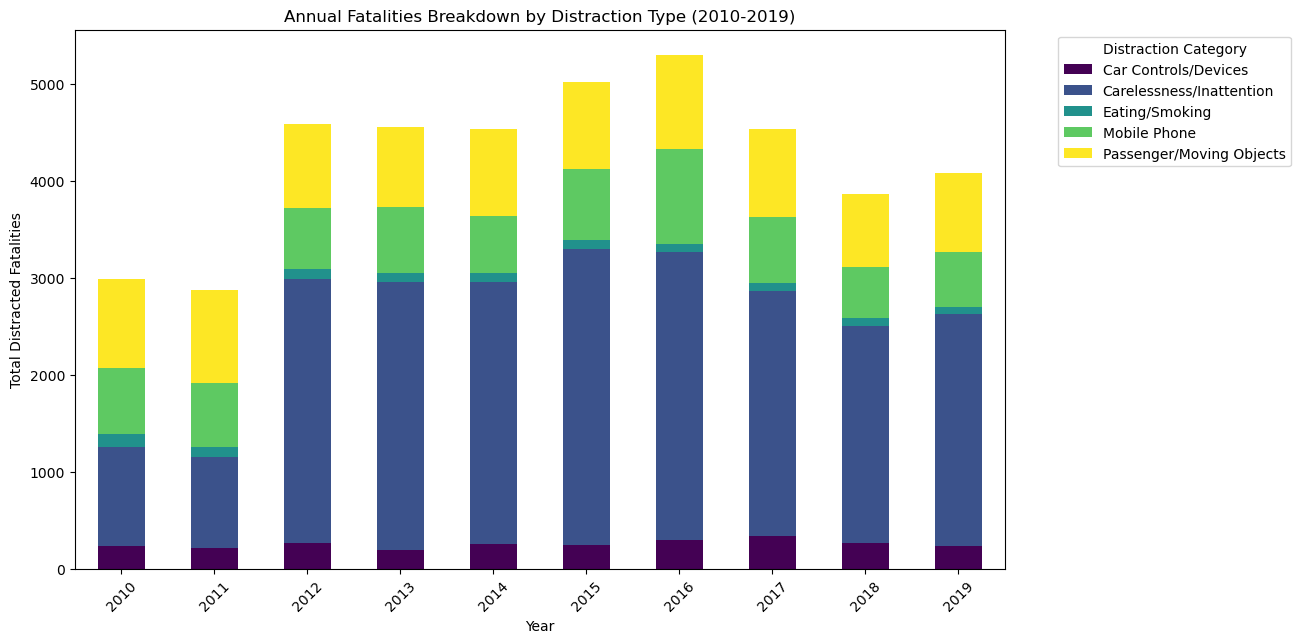

In [17]:
composition_df = df_distracted.groupby(['YEAR', 'DISTRACT_GROUP'])['FATALS'].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 7))

# Plot the raw counts as a stacked bar chart
composition_df.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='viridis'  # Use a color map for variety
)

plt.title('Annual Fatalities Breakdown by Distraction Type (2010-2019)')
plt.xlabel('Year')
plt.ylabel('Total Distracted Fatalities')
plt.xticks(rotation=45)
plt.legend(title='Distraction Category',
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()